<a href="https://colab.research.google.com/github/Laiba-dev569/covid19-data-cleaning-pipeline/blob/main/Covid_19_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print("Pandas Version:", pd.__version__)
print("Numpy Version:", pd.__version__)

Pandas Version: 2.2.2
Numpy Version: 2.2.2


In [ ]:
data = pd.read_csv("/covid_19.csv")

In [ ]:
print("--- First 5 Rows ---")
print(data.head())

print("\n--- Last 5 Rows ---")
print(data.tail())

print("\n--- Dataset Shape ---")
print(f"Shape: {data.shape}")
print(f"  → {data.shape[0]} rows, {data.shape[1]} columns")

print("\n--- Dataset Description ---")
print(data.describe())

print("\n--- Columns List ---")
print(data.columns.tolist())

print("\n--- Data Types & Information ---")
data.info()

--- First 5 Rows ---
            country      continent  population         day  \
0      Saint-Helena         Africa      6115.0  2024-06-30   
1  Falkland-Islands  South-America      3539.0  2024-06-30   
2        Montserrat  North-America      4965.0  2024-06-30   
3  Diamond-Princess            NaN         NaN  2024-06-30   
4      Vatican-City         Europe       799.0  2024-06-30   

                        time  Cases  Recovered  Deaths    Tests  
0  2024-06-30T16:15:16+00:00   2166        2.0     NaN      NaN  
1  2024-06-30T16:15:16+00:00   1930     1930.0     NaN   8632.0  
2  2024-06-30T16:15:16+00:00   1403     1376.0     8.0  17762.0  
3  2024-06-30T16:15:16+00:00    712      699.0    13.0      NaN  
4  2024-06-30T16:15:16+00:00     29       29.0     NaN      NaN  

--- Last 5 Rows ---
         country      continent   population         day  \
233    Argentina  South-America   46010234.0  2024-06-30   
234  Netherlands         Europe   17211447.0  2024-06-30   
235      

Missing Values Before Cleaning:
country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64


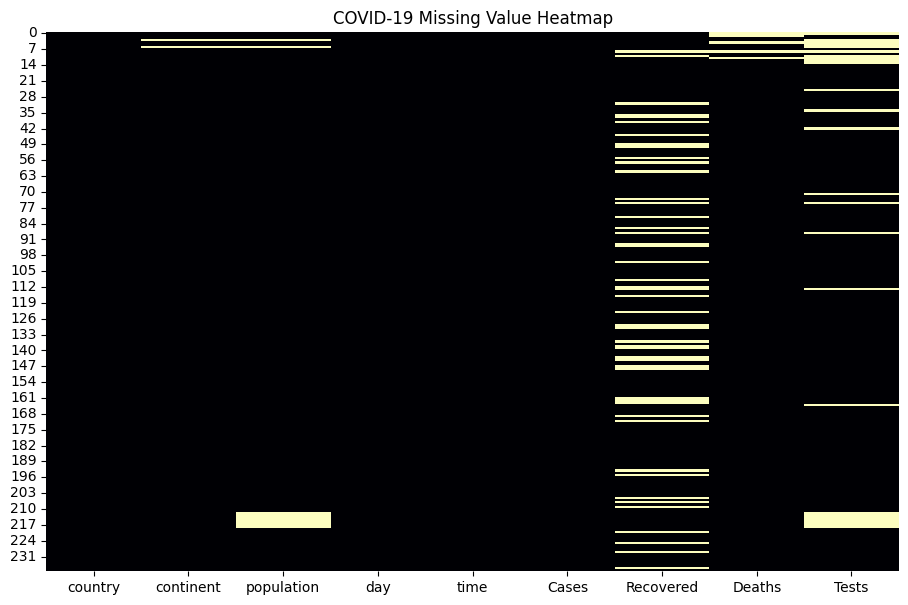

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check missing value numbers per column
print("Missing Values Before Cleaning:")
print(data.isnull().sum())

# Generate and display the missing value map
plt.figure(figsize=(11,7))
sns.heatmap(data.isnull(), cbar=False, cmap='magma')
plt.title("COVID-19 Missing Value Heatmap")
plt.show()

In [ ]:
countries = data["country"]
cases_and_deaths = data[["country", "Cases", "Deaths"]]
print(cases_and_deaths.head())

            country  Cases  Deaths
0      Saint-Helena   2166     NaN
1  Falkland-Islands   1930     NaN
2        Montserrat   1403     8.0
3  Diamond-Princess    712    13.0
4      Vatican-City     29     NaN


In [ ]:
print("\nRow index label 0:")
print(data.loc[0])

print("\nRows 2 through 5, selecting only Country and Cases:")
print(data.loc[2:5, ["country", "Cases"]])


Row index label 0:
country                    Saint-Helena
continent                        Africa
population                       6115.0
day                          2024-06-30
time          2024-06-30T16:15:16+00:00
Cases                              2166
Recovered                           2.0
Deaths                              NaN
Tests                               NaN
Name: 0, dtype: object

Rows 2 through 5, selecting only Country and Cases:
            country  Cases
2        Montserrat   1403
3  Diamond-Princess    712
4      Vatican-City     29
5    Western-Sahara     10


In [ ]:
print("\nFirst 3 row and first 3 columns")
print(data.iloc[0:3, 0:3])


First 3 row and first 3 columns
            country      continent  population
0      Saint-Helena         Africa      6115.0
1  Falkland-Islands  South-America      3539.0
2        Montserrat  North-America      4965.0


In [ ]:
#Isolate countries where global cases cross 10 Million
high_volume_mask = data["Cases"] > 10000000
print("Rows matching > 10M cases:")
print(data[high_volume_mask])

Rows matching > 10M cases:
           country      continent    population         day  \
211          Spain         Europe  4.671914e+07  2024-06-30   
212  North-America  North-America           NaN  2024-06-30   
213           Asia           Asia           NaN  2024-06-30   
214         Europe         Europe           NaN  2024-06-30   
215  South-America  South-America           NaN  2024-06-30   
216        Oceania        Oceania           NaN  2024-06-30   
217         Africa         Africa           NaN  2024-06-30   
218            All            All           NaN  2024-06-30   
219            USA  North-America  3.348053e+08  2024-06-30   
220          India           Asia  1.406632e+09  2024-06-30   
221         France         Europe  6.558452e+07  2024-06-30   
222        Germany         Europe  8.388360e+07  2024-06-30   
223         Brazil  South-America  2.153536e+08  2024-06-30   
224        S-Korea           Asia  5.132990e+07  2024-06-30   
225          Japan          

In [ ]:
#Multiple conditions (Europe continent AND more than 100,000 Deaths)
europe_high_deaths = data[(data["continent"] == "Europe") & (data["Deaths"] > 100000)]
print("\nEuropean regions with > 100k deaths:")
print(europe_high_deaths[["country", "Cases", "Deaths"]])


European regions with > 100k deaths:
     country      Cases     Deaths
168  Ukraine    5557995   112418.0
169   Poland    6661991   120598.0
211    Spain   13914811   121760.0
214   Europe  253406198  2101824.0
221   France   40138560   167642.0
222  Germany   38828995   183027.0
226    Italy   26723249   196487.0
227       UK   24910387   232112.0
228   Russia   24124215   402756.0


In [ ]:
#Multiple conditions (Europe continent AND more than 100,000 Deaths)
europe_high_deaths = data[(data["continent"] == "Europe") & (data["Deaths"] > 100000)]
print("\nEuropean regions with > 100k deaths:")
print(europe_high_deaths[["country", "Cases", "Deaths"]])


European regions with > 100k deaths:
     country      Cases     Deaths
168  Ukraine    5557995   112418.0
169   Poland    6661991   120598.0
211    Spain   13914811   121760.0
214   Europe  253406198  2101824.0
221   France   40138560   167642.0
222  Germany   38828995   183027.0
226    Italy   26723249   196487.0
227       UK   24910387   232112.0
228   Russia   24124215   402756.0


In [ ]:
cleaned_data = data.copy()

In [ ]:
#Clean hidden whitespace and standardise string cases
cleaned_data["country"] = cleaned_data["country"].str.strip().str.title()
cleaned_data["continent"] = cleaned_data["continent"].str.strip().str.title()

In [ ]:
#Track down and report duplicate metrics
print(f"Total Duplicate Rows Found: {cleaned_data.duplicated().sum()}")

Total Duplicate Rows Found: 0


In [ ]:
#Handle missing values safely (fillna)
# Filling missing continents with a placeholder category
cleaned_data["continent"] = cleaned_data["continent"].fillna("Unknown")

In [ ]:
cleaned_data.to_csv("/content/covid_19_cleaned_output.csv", index=False)

In [ ]:
print("\nMissing Values After Final Cleaning:")
print(cleaned_data.isnull().sum())
print("\nOur COVID-19 Data Is Now Clean! File saved to workspace.")


Missing Values After Final Cleaning:
country        0
continent      0
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

Our COVID-19 Data Is Now Clean! File saved to workspace.
